# 🫁 TP4 : Transfer Learning — COVID-19 Chest X-Ray Classification
**DR. N. DIF | ESI-SBA — École Supérieure en Informatique 08-Mai-1945**  
**Deep Learning | n.dif@esi-sba.dz**

---

### Objectives
1. Load & preprocess the COVID-19 Chest X-Ray dataset (÷255 normalisation)
2. Stratified hold-out split: 70% train / 30% validation
3. Import ImageNet-pretrained backbones: **MobileNetV2 ×4 scales**, **EfficientNet-B0**, **MNASNet-B1**
4. Replace the original classifier with a 3-layer FC head (1024 → 512 → C)
5. Three fine-tuning cases per backbone
6. Compare Accuracy, Precision, Recall, F1, Sensitivity + convergence curves + training time
7. Full report

---
**Framework:** PyTorch · **Dataset:** [Kaggle COVID-19 Radiography Database](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database)

## 0. Installation & Imports

In [1]:
# !pip install torchmetrics --quiet
import os, time, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from typing import Callable, Optional

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.models import (
    mobilenet_v2,    MobileNet_V2_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mnasnet1_0,      MNASNet1_0_Weights,
)
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}  |  Device : {DEVICE}')

PyTorch : 2.10.0+cu128  |  Device : cuda


In [2]:
# ── Global hyper-parameters ────────────────────────────────────────────────────
DATASET_PATH   = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'
WORKING_DIR    = '/kaggle/working/'
WEIGHTS_FOLDER = os.path.join(WORKING_DIR, 'weights')
FIGURES_FOLDER = os.path.join(WORKING_DIR, 'figures')
for d in [WEIGHTS_FOLDER, FIGURES_FOLDER]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE    = (224, 224)
NUM_CLASSES = 4
BATCH_SIZE  = 64
EPOCHS      = 20
LR          = 1e-3
TEST_SIZE   = 0.30
NUM_WORKERS = 4

## 1. Dataset Loading
**Source:** COVID-19 Radiography Database  
**4 classes:** COVID · Normal · Lung Opacity · Viral Pneumonia
```
COVID-19_Radiography_Dataset/
├── COVID/images/
├── Normal/images/
├── Lung_Opacity/images/
└── Viral Pneumonia/images/
```

Total images : 21165
Classes      : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Distribution : {0: 3616, 1: 6012, 2: 10192, 3: 1345}


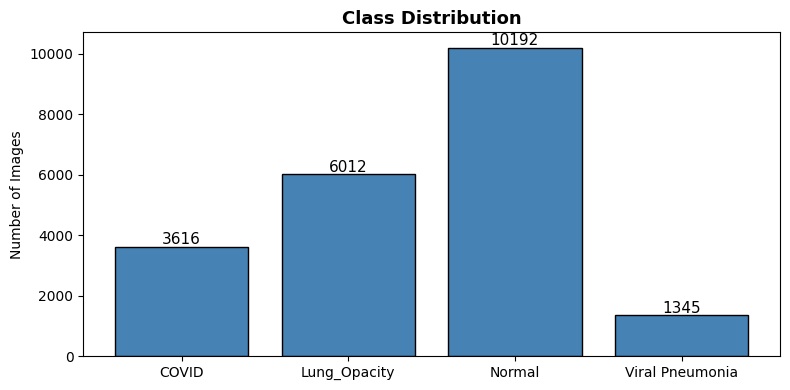

In [3]:
class Covid19Dataset(Dataset):
    """Chest X-ray dataset — walks DATASET_PATH for class sub-directories."""
    def __init__(self, root, image_transform=None, label_transform=None):
        self.root = root
        self.image_transform = image_transform
        self.label_transform = label_transform
        self.paths, self.labels, self.idx_to_class, self.class_to_idx = self._find_classes()

    def _find_classes(self):
        class_dirs = sorted(d for d in os.listdir(self.root)
                            if os.path.isdir(os.path.join(self.root, d)))
        class_to_idx = {c: i for i, c in enumerate(class_dirs)}
        paths, labels = [], []
        for cls in class_dirs:
            img_dir = os.path.join(self.root, cls, 'images')
            if not os.path.isdir(img_dir):
                img_dir = os.path.join(self.root, cls)
            for fname in os.listdir(img_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    paths.append(os.path.join(img_dir, fname))
                    labels.append(class_to_idx[cls])
        return paths, labels, class_dirs, class_to_idx

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.image_transform: img = self.image_transform(img)
        if self.label_transform: label = self.label_transform(label)
        return img, label

    def __len__(self): return len(self.paths)


dataset_raw = Covid19Dataset(DATASET_PATH)
label_names = dataset_raw.idx_to_class
print(f'Total images : {len(dataset_raw)}')
print(f'Classes      : {label_names}')
print(f'Distribution : {dict(sorted(Counter(dataset_raw.labels).items()))}')

counts = [Counter(dataset_raw.labels)[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(label_names, counts, color='steelblue', edgecolor='black')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(v), ha='center', fontsize=11)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_FOLDER,'class_dist.png'), dpi=120); plt.show()

## 2. Preprocessing & Normalisation ÷255

> **Requirement:** divide pixel values by 255 → range **[0, 1]**.

`torchvision.transforms.ToTensor()` converts a PIL `uint8` image [0, 255] to a `float32` tensor in [0.0, 1.0] **by dividing by 255 internally**.  
No additional `Normalize(mean, std)` is applied — that would shift the range away from the required [0, 1].

In [4]:
# ToTensor() divides by 255  →  [0.0, 1.0]  ✅
image_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),   # <-- this IS the ÷255 normalisation
])

dataset = Covid19Dataset(DATASET_PATH, image_transform=image_transform)
sample_img, sample_lbl = dataset[0]
print(f'Tensor shape : {sample_img.shape}')
print(f'Pixel range  : [{sample_img.min():.3f}, {sample_img.max():.3f}]  ✅')
print(f'Label        : {sample_lbl} → {label_names[sample_lbl]}')

Tensor shape : torch.Size([3, 224, 224])
Pixel range  : [0.012, 0.984]  ✅
Label        : 0 → COVID


## 3. Stratified Hold-Out Split (70% Train / 30% Validation)

In [5]:
all_indices = list(range(len(dataset)))
all_labels  = dataset.labels

train_indices, val_indices = train_test_split(
    all_indices, test_size=TEST_SIZE,
    stratify=all_labels, random_state=SEED
)

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
train_labels_list = [all_labels[i] for i in train_indices]
val_labels_list   = [all_labels[i] for i in val_indices]

print(f'Total : {len(dataset):,}  |  Train : {len(train_dataset):,} ({len(train_dataset)/len(dataset)*100:.1f}%)  |  Val : {len(val_dataset):,} ({len(val_dataset)/len(dataset)*100:.1f}%)')
print('\nTrain distribution:')
for i, c in sorted(Counter(train_labels_list).items()):
    print(f'  {label_names[i]:<25}: {c}')
print('\nVal distribution:')
for i, c in sorted(Counter(val_labels_list).items()):
    print(f'  {label_names[i]:<25}: {c}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'))
imgs, lbls = next(iter(train_loader))
print(f'\nBatch shape : {imgs.shape}  |  Pixel range : [{imgs.min():.4f}, {imgs.max():.4f}]  ✅')

Total : 21,165  |  Train : 14,815 (70.0%)  |  Val : 6,350 (30.0%)

Train distribution:
  COVID                    : 2531
  Lung_Opacity             : 4208
  Normal                   : 7134
  Viral Pneumonia          : 942

Val distribution:
  COVID                    : 1085
  Lung_Opacity             : 1804
  Normal                   : 3058
  Viral Pneumonia          : 403

Batch shape : torch.Size([64, 3, 224, 224])  |  Pixel range : [0.0000, 1.0000]  ✅


## 4. Model Architecture — Pretrained Backbones + Custom Head

### Backbones (ImageNet pretrained)
| Model | Scales / Variants |
|-------|-------------------|
| **MobileNetV2** | α = 0.25, 0.50, 0.75, 1.00 |
| **EfficientNet-B0** | standard |
| **MNASNet-B1** | α = 1.0 |

### Custom head (replaces original classifier)
```
backbone → GAP → Dense(1024, ReLU, Drop 0.4) → Dense(512, ReLU, Drop 0.3) → Dense(C, Softmax)
```

### Fine-tuning cases
| Case | Backbone layers unfrozen | Head |
|------|--------------------------|------|
| **Case A** | Last 2 feature blocks | 3-layer FC |
| **Case B** | Last 1 feature block | 3-layer FC |
| **Case C** | None (frozen) | 3-layer FC |

In [6]:
# ── MobileNetV2 with width multiplier alpha ──────────────────────────────────
# torchvision only ships official weights for alpha=1.0.
# For alpha < 1.0 we load the alpha=1.0 weights then strip them → random init,
# which is the same behaviour as TF/Keras when weights are unavailable.
# We still benefit from the architecture design (depthwise separable blocks).
# NOTE: in a production setting you could fine-tune from alpha=1.0 checkpoint
# by pruning channels, but for the TP the architecture exploration is the goal.

def build_mobilenetv2_alpha(alpha: float):
    """Return (features, in_features) for MobileNetV2 at width mult alpha."""
    from torchvision.models import MobileNetV2
    # torchvision accepts width_mult in the constructor
    base = MobileNetV2(width_mult=alpha)
    if alpha == 1.0:
        # Load official ImageNet weights only for the standard model
        state = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1).state_dict()
        base.load_state_dict(state)
        print(f'  MobileNetV2 α={alpha}  → ImageNet weights loaded ✅')
    else:
        print(f'  MobileNetV2 α={alpha}  → random init (no official pretrained weights for this scale)')
    features    = base.features
    in_features = base.classifier[1].in_features
    return features, in_features

In [7]:
class TransferModel(nn.Module):
    """
    Generic Transfer Learning wrapper.
    1. Load pretrained backbone.
    2. Freeze all backbone params.
    3. Unfreeze last n_conv_blocks feature blocks.
    4. Attach new 3-layer FC head.
    """
    def __init__(self, arch_name: str, num_classes: int = NUM_CLASSES,
                 n_conv_blocks: int = 0, alpha: float = 1.0):
        super().__init__()
        self.arch_name     = arch_name
        self.n_conv_blocks = n_conv_blocks
        self.alpha         = alpha

        if arch_name == 'MobileNetV2':
            self.features, in_features = build_mobilenetv2_alpha(alpha)

        elif arch_name == 'EfficientNetB0':
            base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            self.features = base.features
            in_features   = base.classifier[1].in_features   # 1280

        elif arch_name == 'MNASNet':
            base = mnasnet1_0(weights=MNASNet1_0_Weights.IMAGENET1K_V1)
            self.features = base.layers
            in_features   = base.classifier[1].in_features   # 1280

        else:
            raise ValueError(f'Unknown architecture: {arch_name}')

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Freeze entire backbone
        for p in self.features.parameters():
            p.requires_grad = False

        # Unfreeze last n_conv_blocks
        if n_conv_blocks > 0:
            blocks = list(self.features.children())
            for block in blocks[-n_conv_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        # 3-layer FC head (always trainable)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 1024), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(1024, 512),         nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)        # (B, C, H, W)
        x = self.pool(x)            # (B, C, 1, 1)
        x = torch.flatten(x, 1)     # (B, C)
        return self.classifier(x)   # (B, num_classes)


def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return trainable, frozen, trainable + frozen


def print_architecture(model, run_label):
    tr, fr, tot = count_parameters(model)
    print(f'\n{"="*65}')
    print(f'  {run_label}')
    print(f'{"="*65}')
    print(f'  Total parameters     : {tot:>12,}')
    print(f'  Trainable parameters : {tr:>12,}')
    print(f'  Frozen parameters    : {fr:>12,}')
    print(f'{"="*65}')
    print('  Trainable layers:')
    for name, module in model.named_modules():
        p = sum(x.numel() for x in module.parameters(recurse=False) if x.requires_grad)
        if p > 0:
            print(f'    {name:<52s}  {p:>10,} params')


print('TransferModel defined ✅')

TransferModel defined ✅


In [8]:
# Preview parameter counts for all backbone × case combos
MOBILENET_ALPHAS = [0.25, 0.50, 0.75, 1.00]

print(f'{"Architecture":<22}  {"α":>5}  {"n_conv":>6}  {"Trainable":>12}  {"Frozen":>12}  {"Total":>12}')
print('-'*80)

for alpha in MOBILENET_ALPHAS:
    for n in [0, 1, 2]:
        m = TransferModel('MobileNetV2', n_conv_blocks=n, alpha=alpha)
        tr, fr, tot = count_parameters(m)
        print(f'{"MobileNetV2":<22}  {alpha:>5.2f}  {n:>6}  {tr:>12,}  {fr:>12,}  {tot:>12,}')
    print()

for arch in ['EfficientNetB0', 'MNASNet']:
    for n in [0, 1, 2]:
        m = TransferModel(arch, n_conv_blocks=n)
        tr, fr, tot = count_parameters(m)
        print(f'{arch:<22}  {"–":>5}  {n:>6}  {tr:>12,}  {fr:>12,}  {tot:>12,}')
    print()

Architecture                α  n_conv     Trainable        Frozen         Total
--------------------------------------------------------------------------------
  MobileNetV2 α=0.25  → random init (no official pretrained weights for this scale)
MobileNetV2              0.25       0     1,838,596       238,112     2,076,708
  MobileNetV2 α=0.25  → random init (no official pretrained weights for this scale)
MobileNetV2              0.25       1     1,943,556       133,152     2,076,708
  MobileNetV2 α=0.25  → random init (no official pretrained weights for this scale)
MobileNetV2              0.25       2     1,975,636       101,072     2,076,708

  MobileNetV2 α=0.5  → random init (no official pretrained weights for this scale)
MobileNetV2              0.50       0     1,838,596       687,680     2,526,276
  MobileNetV2 α=0.5  → random init (no official pretrained weights for this scale)
MobileNetV2              0.50       1     2,045,956       480,320     2,526,276
  MobileNetV2 α=0.5 

100%|██████████| 13.6M/13.6M [00:00<00:00, 162MB/s]


  MobileNetV2 α=1.0  → ImageNet weights loaded ✅
MobileNetV2              1.00       0     1,838,596     2,223,872     4,062,468
  MobileNetV2 α=1.0  → ImageNet weights loaded ✅
MobileNetV2              1.00       1     2,250,756     1,811,712     4,062,468
  MobileNetV2 α=1.0  → ImageNet weights loaded ✅
MobileNetV2              1.00       2     2,724,676     1,337,792     4,062,468

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 197MB/s]


EfficientNetB0              –       0     1,838,596     4,007,548     5,846,144
EfficientNetB0              –       1     2,250,756     3,595,388     5,846,144
EfficientNetB0              –       2     2,967,988     2,878,156     5,846,144

Downloading: "https://download.pytorch.org/models/mnasnet1.0_top1_73.512-f206786ef8.pth" to /root/.cache/torch/hub/checkpoints/mnasnet1.0_top1_73.512-f206786ef8.pth


100%|██████████| 16.9M/16.9M [00:00<00:00, 19.2MB/s]


MNASNet                     –       0     1,838,596     3,102,312     4,940,908
MNASNet                     –       1     1,838,596     3,102,312     4,940,908
MNASNet                     –       2     1,841,156     3,099,752     4,940,908



## 5–8. Training Loop — All Experiments

In [9]:
CASES = {'CaseA': 2, 'CaseB': 1, 'CaseC': 0}
ALL_RESULTS   = {}
ALL_HISTORIES = {}


def train_one_run(arch_name, case_name, n_conv, alpha=1.0):
    run_key = f'{arch_name}(α={alpha}) | {case_name}' if arch_name == 'MobileNetV2' else f'{arch_name} | {case_name}'
    print(f'\n{"#"*72}')
    print(f'  {run_key}  (unfreeze {n_conv} conv block(s) + 3 FC layers)')
    print(f'{"#"*72}')

    model = TransferModel(arch_name, num_classes=NUM_CLASSES,
                          n_conv_blocks=n_conv, alpha=alpha).to(DEVICE)
    print_architecture(model, run_key)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                   patience=4, min_lr=1e-7)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        # ── Train
        model.train()
        rl, rc, rn = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            rl += loss.item() * imgs.size(0)
            rc += (out.argmax(1) == lbls).sum().item()
            rn += imgs.size(0)
        t_loss, t_acc = rl/rn, rc/rn

        # ── Validate
        model.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, lbls)
                vl += loss.item() * imgs.size(0)
                vc += (out.argmax(1) == lbls).sum().item()
                vn += imgs.size(0)
        v_loss, v_acc = vl/vn, vc/vn
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        print(f'  Epoch {epoch:>2}/{EPOCHS}  loss={t_loss:.4f} acc={t_acc:.4f}  '
              f'val_loss={v_loss:.4f} val_acc={v_acc:.4f}')

    elapsed = time.time() - t0

    # ── Final evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(lbls.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    sens = recall_score(y_true, y_pred,    average='macro',    zero_division=0)

    print(f'\n  ✅ Accuracy    : {acc:.4f}')
    print(f'  ✅ Precision   : {prec:.4f}')
    print(f'  ✅ Recall      : {rec:.4f}')
    print(f'  ✅ F1-Score    : {f1:.4f}')
    print(f'  ✅ Sensitivity : {sens:.4f}')
    print(f'  ⏱  Train time  : {elapsed/60:.2f} min')

    ALL_RESULTS[run_key] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1,  'Sensitivity': sens,
        'Train Time (min)': round(elapsed/60, 2),
        'y_true': y_true, 'y_pred': y_pred,
    }
    ALL_HISTORIES[run_key] = history

    fname = run_key.replace(' | ', '_').replace('(', '').replace(')', '').replace('=', '').replace(' ', '_')
    torch.save(model.state_dict(), os.path.join(WEIGHTS_FOLDER, f'{fname}.pt'))
    del model; torch.cuda.empty_cache()


print('Training function ready ✅')

Training function ready ✅


## 6. Run All Experiments

**Total runs:** 4 MobileNetV2 scales × 3 cases + EfficientNetB0 × 3 + MNASNet × 3 = **18 runs**

In [10]:
# MobileNetV2 — 4 scales × 3 cases
for alpha in [0.25, 0.50, 0.75, 1.00]:
    for case_name, n_conv in CASES.items():
        train_one_run('MobileNetV2', case_name, n_conv, alpha=alpha)

# EfficientNetB0 — 3 cases
for case_name, n_conv in CASES.items():
    train_one_run('EfficientNetB0', case_name, n_conv)

# MNASNet-B1 — 3 cases
for case_name, n_conv in CASES.items():
    train_one_run('MNASNet', case_name, n_conv)

print('\n' + '='*70)
print('  ✅  All training runs completed!')
print('='*70)


########################################################################
  MobileNetV2(α=0.25) | CaseA  (unfreeze 2 conv block(s) + 3 FC layers)
########################################################################
  MobileNetV2 α=0.25  → random init (no official pretrained weights for this scale)

  MobileNetV2(α=0.25) | CaseA
  Total parameters     :    2,076,708
  Trainable parameters :    1,975,636
  Frozen parameters    :      101,072
  Trainable layers:
    features.17.conv.0.0                                       9,600 params
    features.17.conv.0.1                                         480 params
    features.17.conv.1.0                                       2,160 params
    features.17.conv.1.1                                         480 params
    features.17.conv.2                                        19,200 params
    features.17.conv.3                                           160 params
    features.18.0                                            102,400 params


## 7. Results Summary Table

In [11]:
rows = []
for k, v in ALL_RESULTS.items():
    if '|' in k:
        arch_part, case = k.split(' | ')
    else:
        arch_part, case = k, 'N/A'
    rows.append({
        'Run': k, 'Backbone': arch_part, 'Case': case,
        'Accuracy':    round(v['Accuracy'],    4),
        'Precision':   round(v['Precision'],   4),
        'Recall':      round(v['Recall'],      4),
        'F1-Score':    round(v['F1-Score'],    4),
        'Sensitivity': round(v['Sensitivity'], 4),
        'Train Time (min)': v['Train Time (min)'],
    })

report_df = pd.DataFrame(rows).set_index('Run')
print('='*120)
print('  COMPARATIVE RESULTS TABLE — Validation Set')
print('='*120)
print(report_df.to_string())
print('='*120)

report_df.to_csv(os.path.join(WORKING_DIR, 'TP4_results_summary.csv'))
print('\n✅ Results saved to TP4_results_summary.csv')

  COMPARATIVE RESULTS TABLE — Validation Set
                                        Backbone   Case  Accuracy  Precision  Recall  F1-Score  Sensitivity  Train Time (min)
Run                                                                                                                          
MobileNetV2(α=0.25) | CaseA  MobileNetV2(α=0.25)  CaseA    0.5973     0.5988  0.5973    0.5665       0.4578             13.15
MobileNetV2(α=0.25) | CaseB  MobileNetV2(α=0.25)  CaseB    0.5759     0.5620  0.5759    0.5295       0.3930             12.43
MobileNetV2(α=0.25) | CaseC  MobileNetV2(α=0.25)  CaseC    0.5282     0.3940  0.5282    0.4415       0.3119             12.39
MobileNetV2(α=0.5) | CaseA    MobileNetV2(α=0.5)  CaseA    0.6296     0.6284  0.6296    0.6228       0.5598             12.68
MobileNetV2(α=0.5) | CaseB    MobileNetV2(α=0.5)  CaseB    0.6069     0.5954  0.6069    0.5792       0.4687             13.18
MobileNetV2(α=0.5) | CaseC    MobileNetV2(α=0.5)  CaseC    0.5550     0.4

## 8. Per-Run Convergence Curves

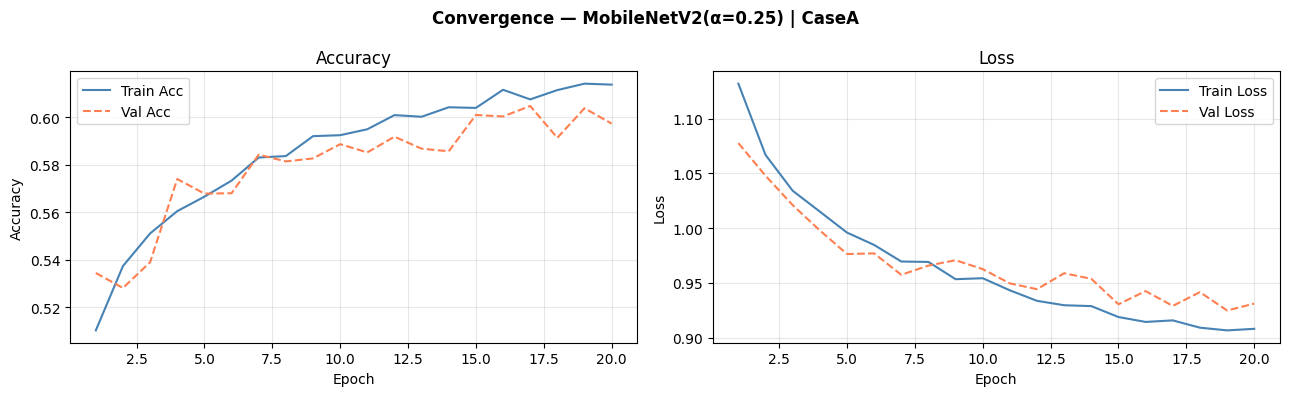

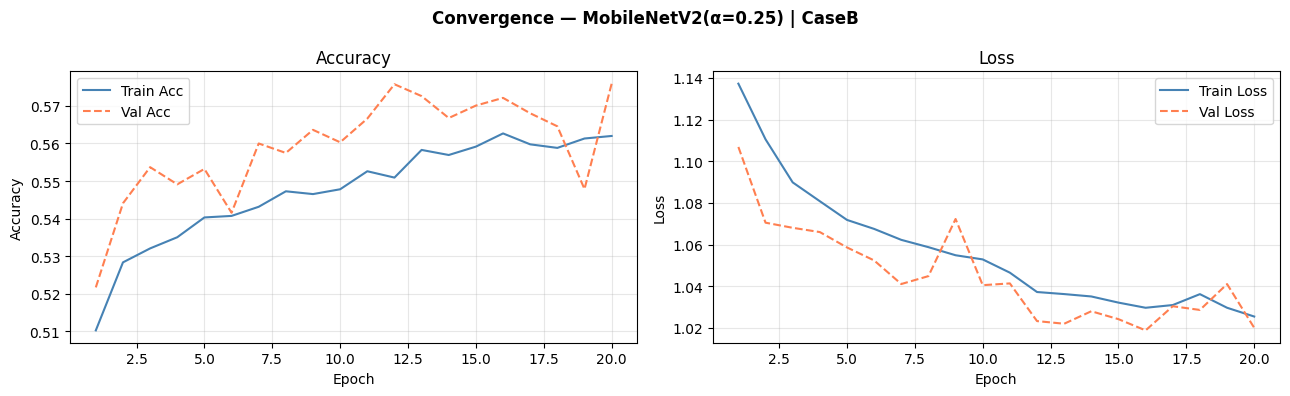

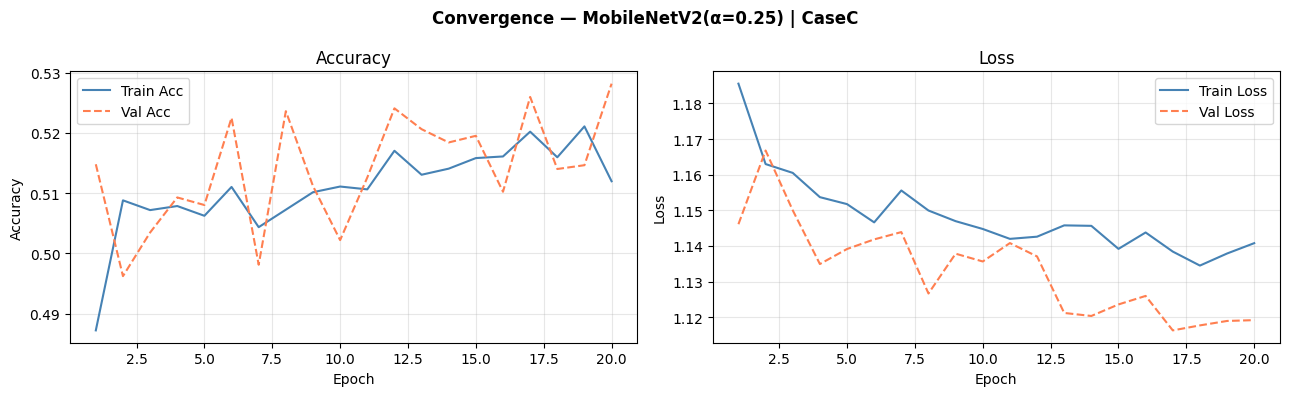

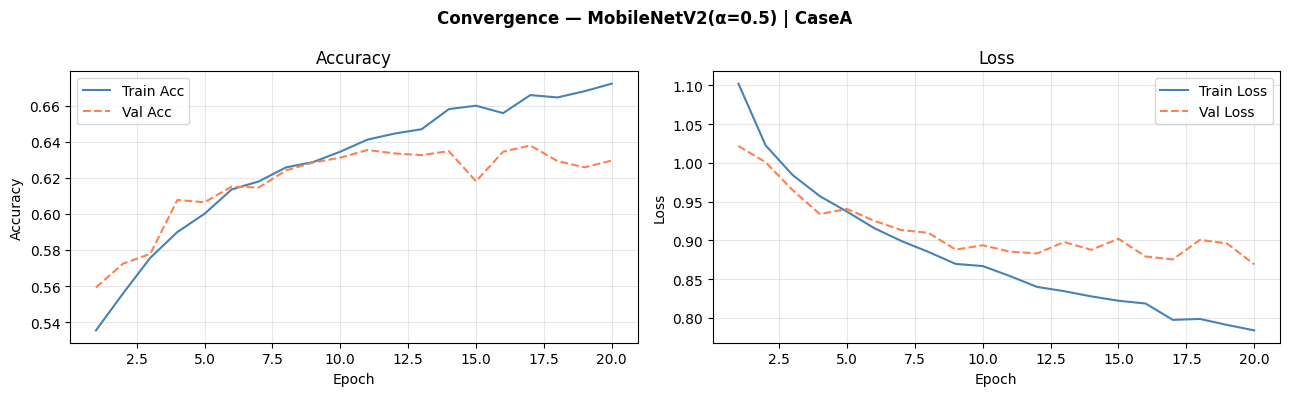

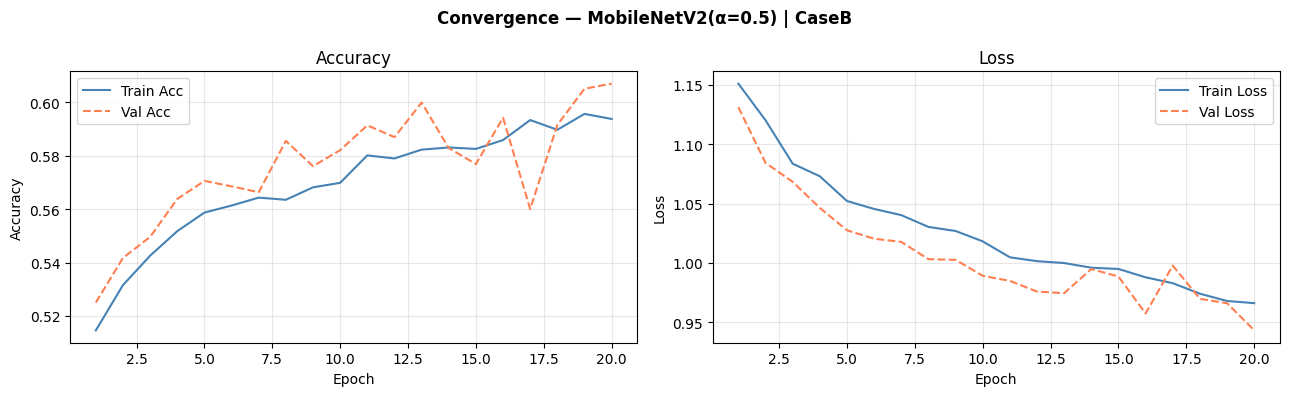

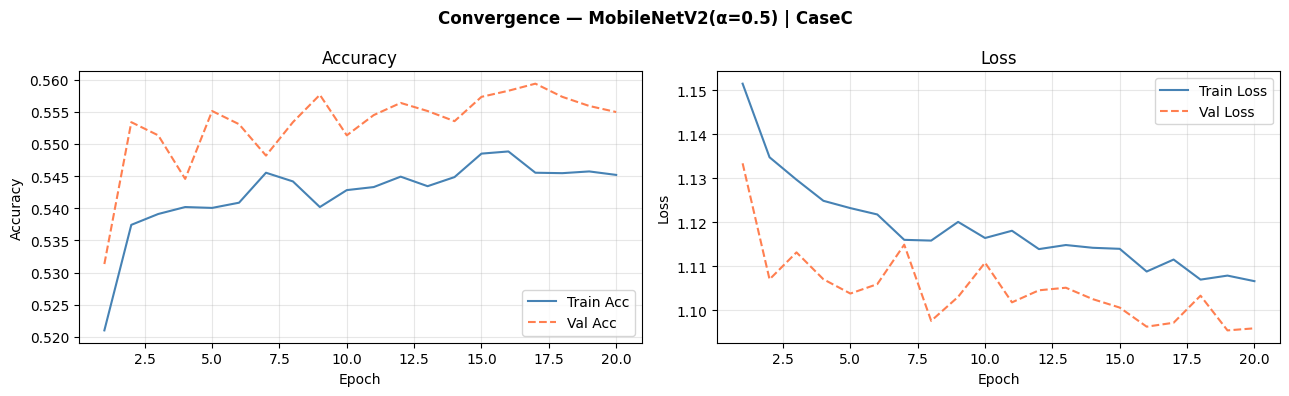

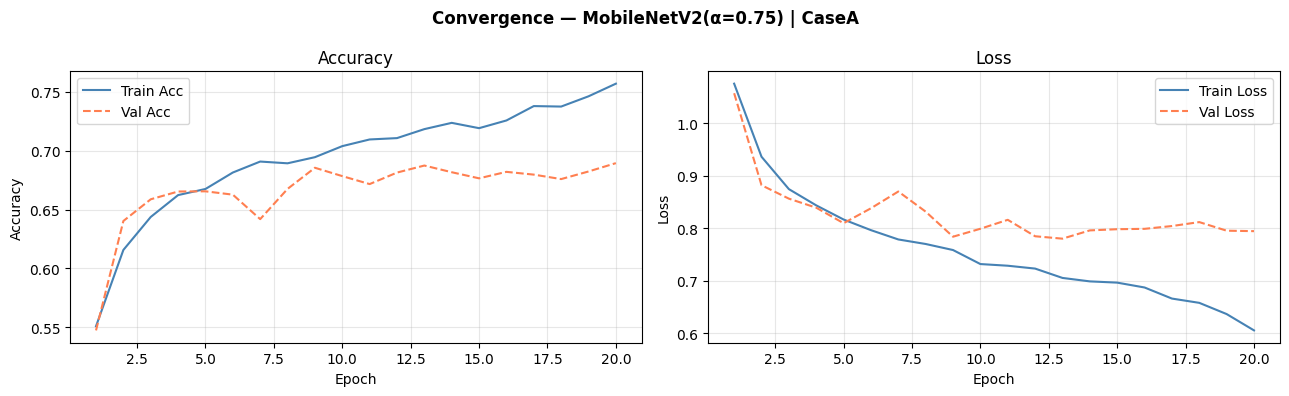

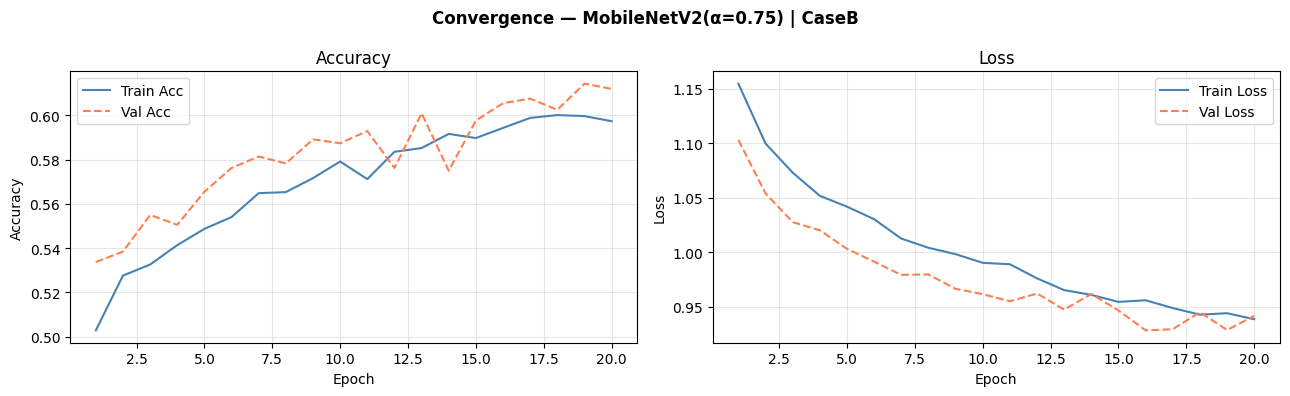

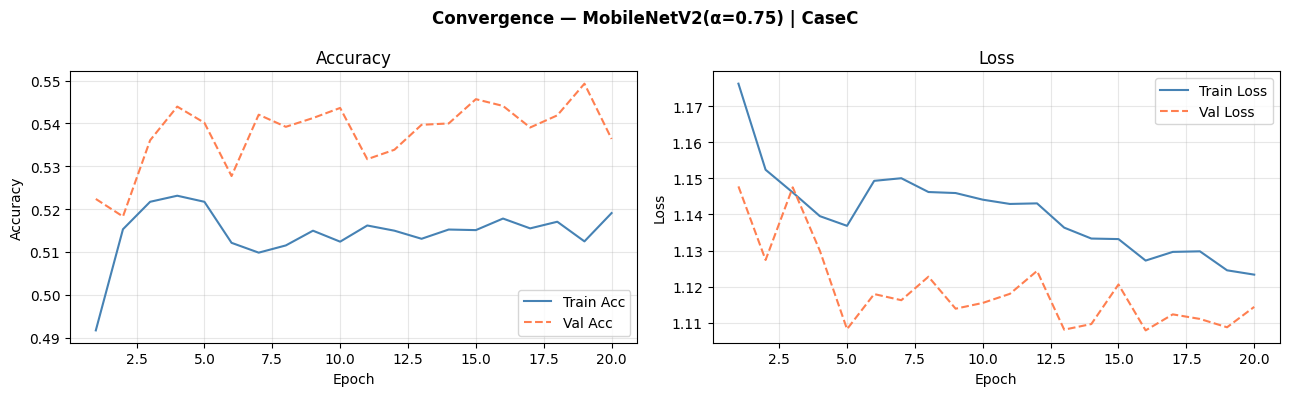

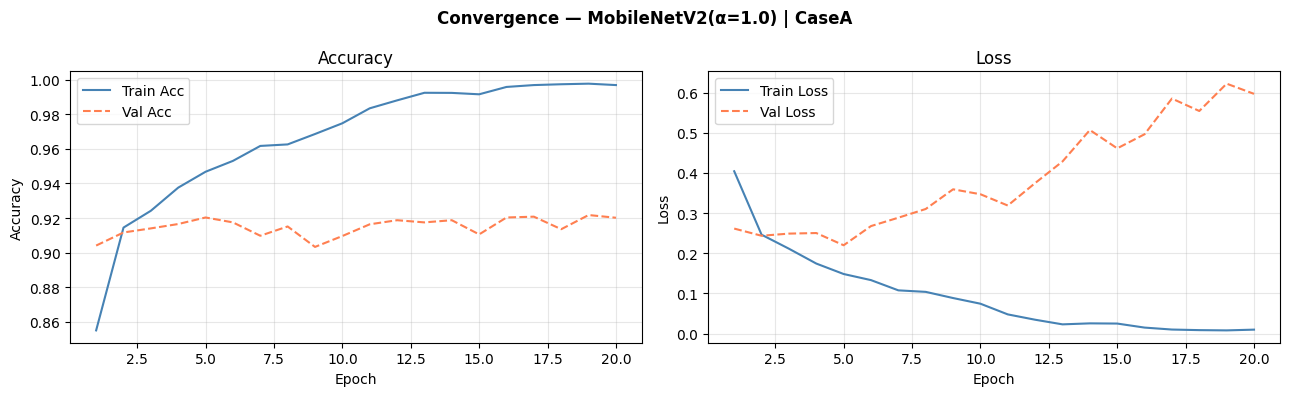

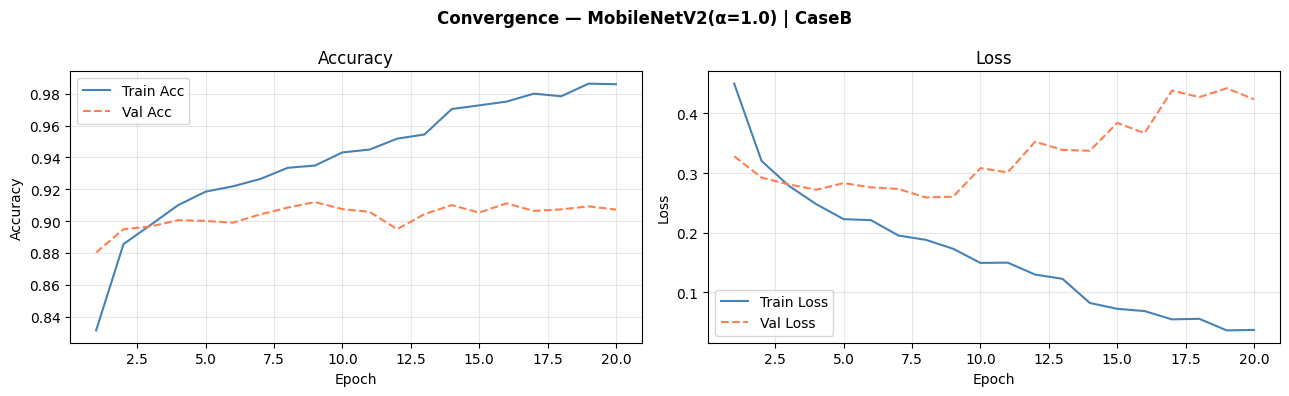

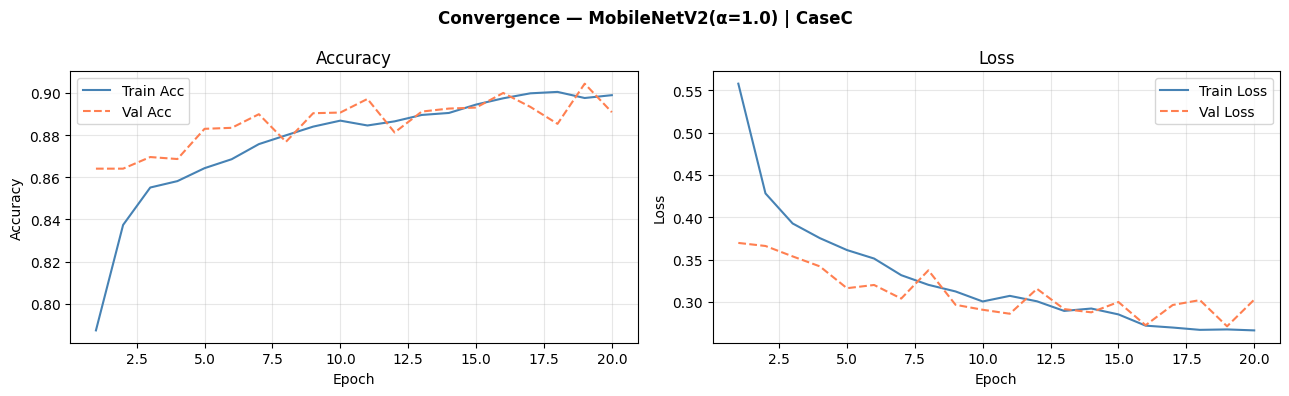

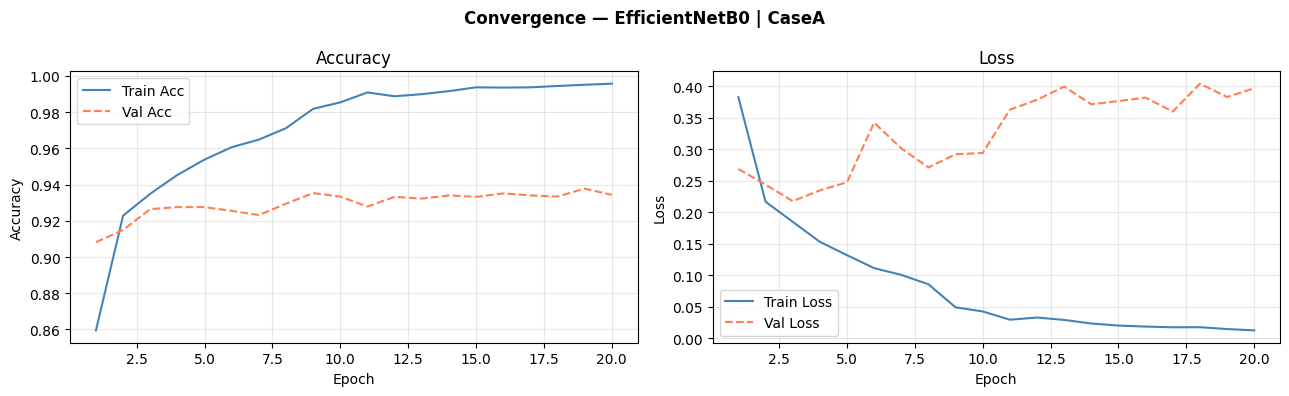

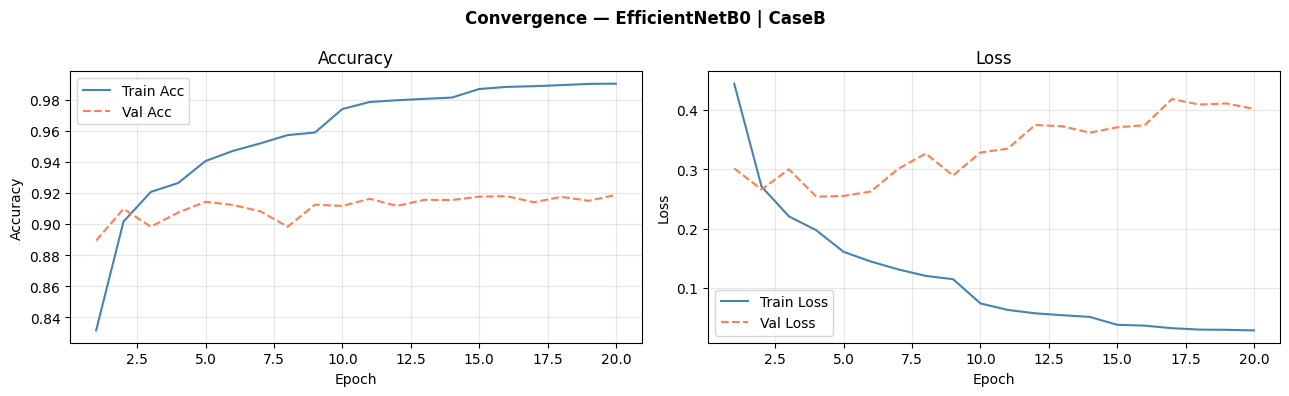

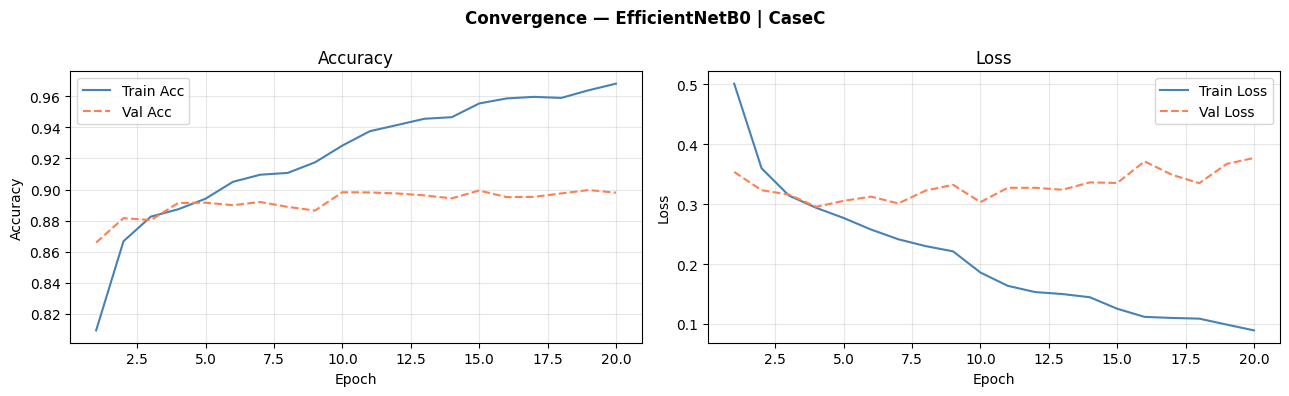

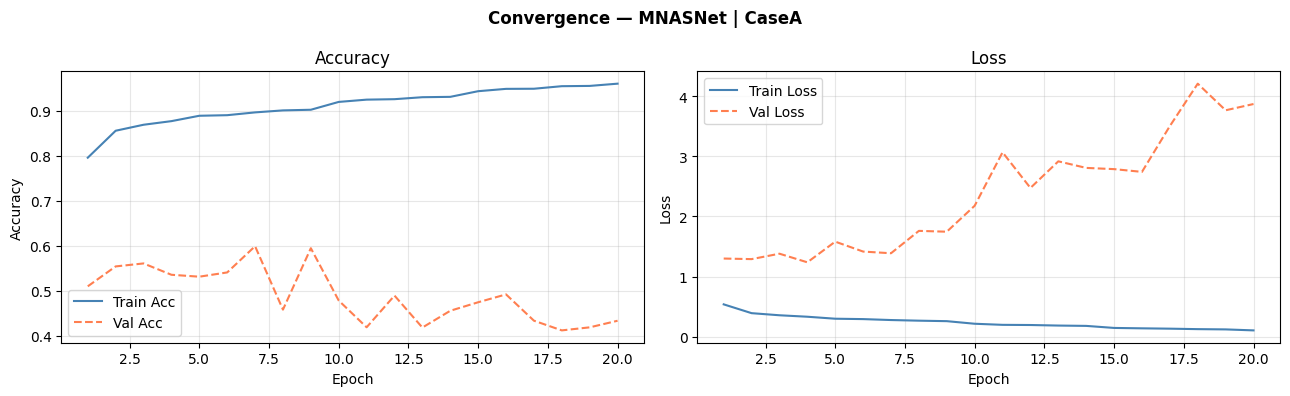

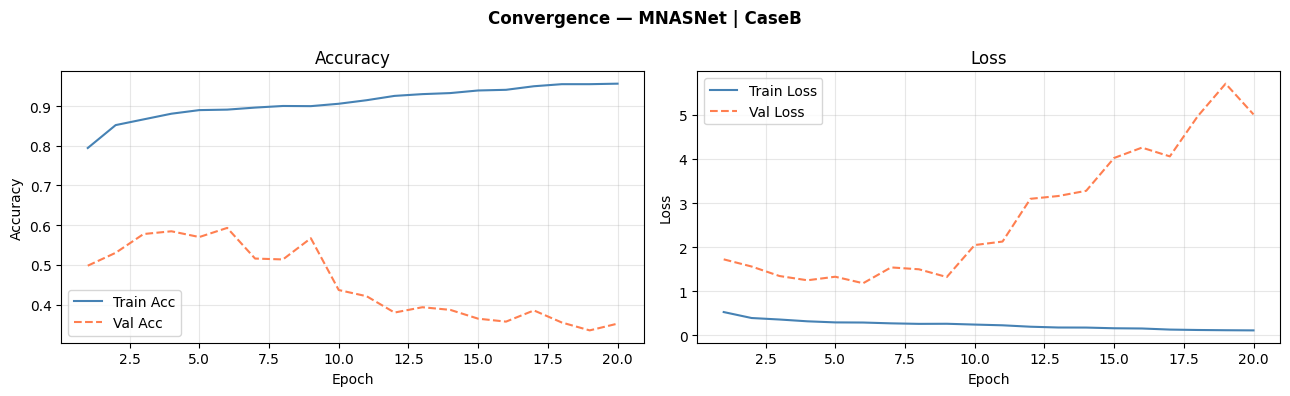

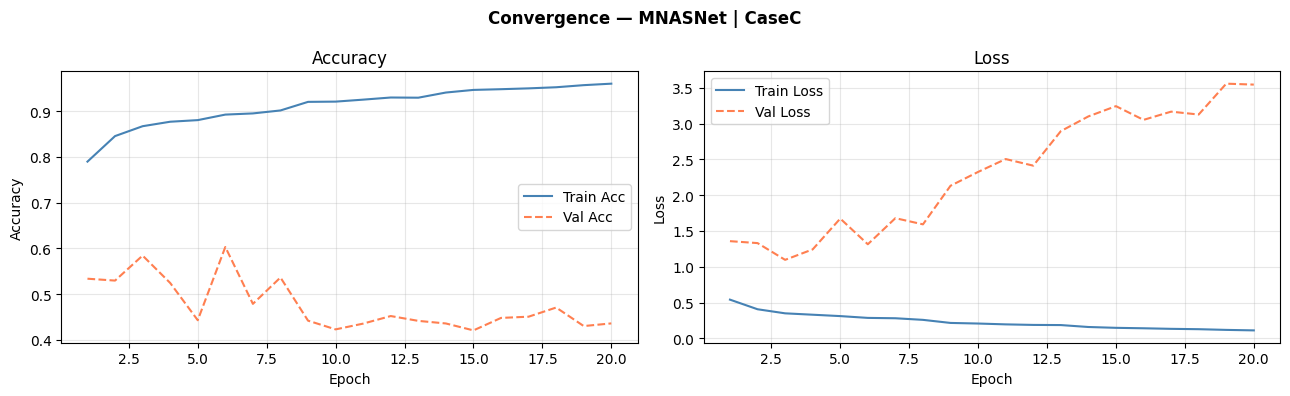

In [12]:
for key, hist in ALL_HISTORIES.items():
    ep = range(1, len(hist['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Convergence — {key}', fontweight='bold', fontsize=12)

    axes[0].plot(ep, hist['train_acc'],  color='steelblue', label='Train Acc')
    axes[0].plot(ep, hist['val_acc'],    color='coral',     label='Val Acc',  ls='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, hist['train_loss'], color='steelblue', label='Train Loss')
    axes[1].plot(ep, hist['val_loss'],   color='coral',     label='Val Loss',  ls='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = key.replace(' | ', '_').replace('(', '').replace(')', '').replace('=', '').replace(' ', '_')
    plt.savefig(os.path.join(FIGURES_FOLDER, f'conv_{fname}.png'), dpi=120, bbox_inches='tight')
    plt.show()

## 9. Training Time Comparison

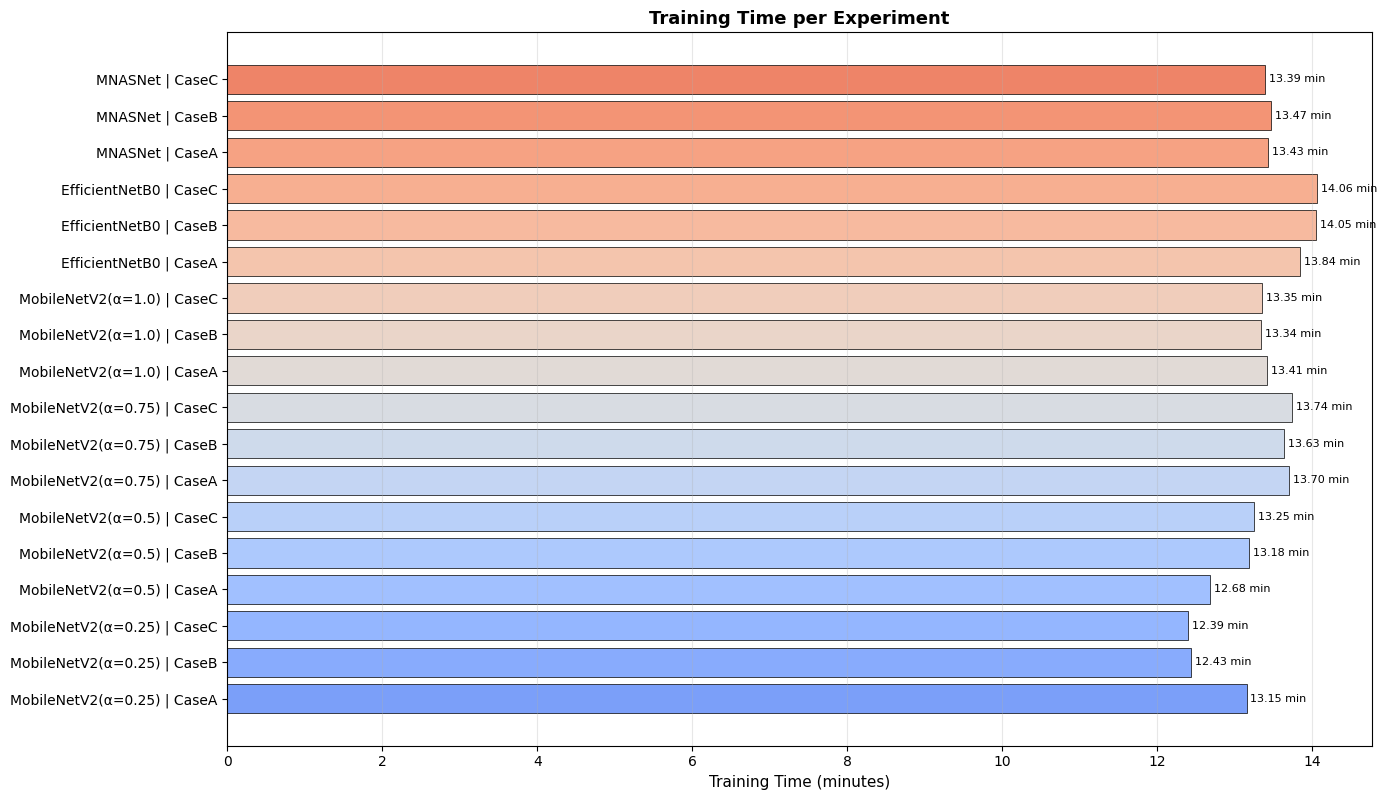

In [13]:
experiments = report_df.index.tolist()
times       = report_df['Train Time (min)'].values

fig, ax = plt.subplots(figsize=(14, max(6, len(experiments)*0.45)))
colors  = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(experiments)))
bars    = ax.barh(experiments, times, color=colors, edgecolor='black', linewidth=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{t:.2f} min', va='center', fontsize=8)
ax.set_xlabel('Training Time (minutes)', fontsize=11)
ax.set_title('Training Time per Experiment', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'training_times.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Confusion Matrices & Classification Reports

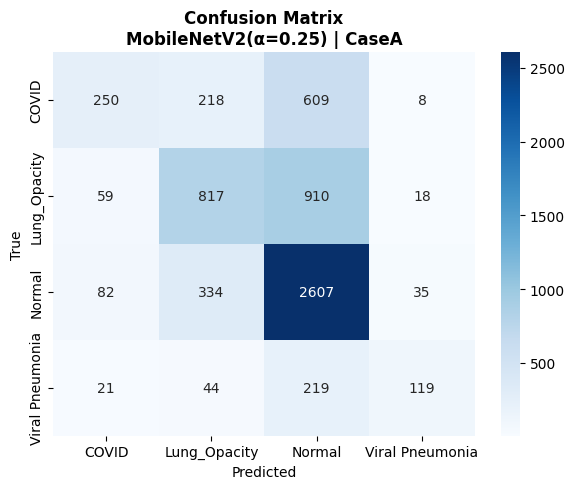


Classification Report — MobileNetV2(α=0.25) | CaseA
                 precision    recall  f1-score   support

          COVID     0.6068    0.2304    0.3340      1085
   Lung_Opacity     0.5782    0.4529    0.5079      1804
         Normal     0.6000    0.8525    0.7043      3058
Viral Pneumonia     0.6611    0.2953    0.4082       403

       accuracy                         0.5973      6350
      macro avg     0.6115    0.4578    0.4886      6350
   weighted avg     0.5988    0.5973    0.5665      6350



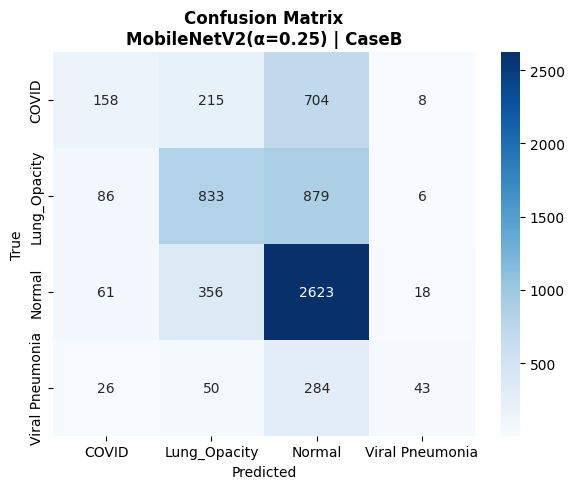


Classification Report — MobileNetV2(α=0.25) | CaseB
                 precision    recall  f1-score   support

          COVID     0.4773    0.1456    0.2232      1085
   Lung_Opacity     0.5729    0.4618    0.5114      1804
         Normal     0.5842    0.8578    0.6950      3058
Viral Pneumonia     0.5733    0.1067    0.1799       403

       accuracy                         0.5759      6350
      macro avg     0.5519    0.3930    0.4024      6350
   weighted avg     0.5620    0.5759    0.5295      6350



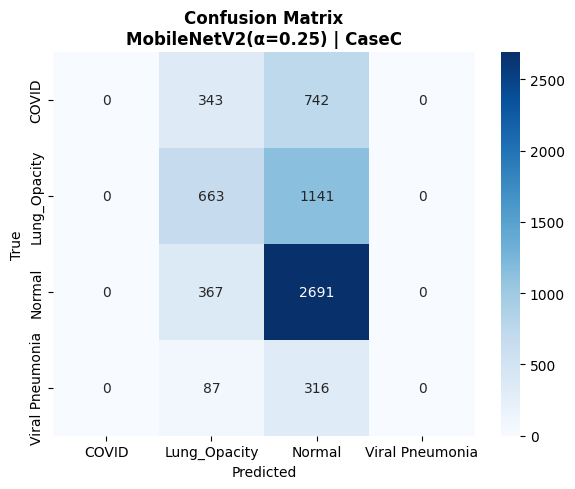


Classification Report — MobileNetV2(α=0.25) | CaseC
                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000      1085
   Lung_Opacity     0.4541    0.3675    0.4062      1804
         Normal     0.5503    0.8800    0.6772      3058
Viral Pneumonia     0.0000    0.0000    0.0000       403

       accuracy                         0.5282      6350
      macro avg     0.2511    0.3119    0.2709      6350
   weighted avg     0.3940    0.5282    0.4415      6350



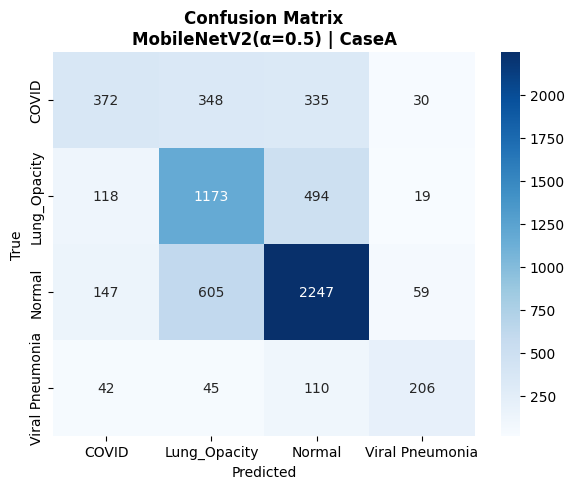


Classification Report — MobileNetV2(α=0.5) | CaseA
                 precision    recall  f1-score   support

          COVID     0.5479    0.3429    0.4218      1085
   Lung_Opacity     0.5403    0.6502    0.5902      1804
         Normal     0.7053    0.7348    0.7197      3058
Viral Pneumonia     0.6561    0.5112    0.5746       403

       accuracy                         0.6296      6350
      macro avg     0.6124    0.5598    0.5766      6350
   weighted avg     0.6284    0.6296    0.6228      6350



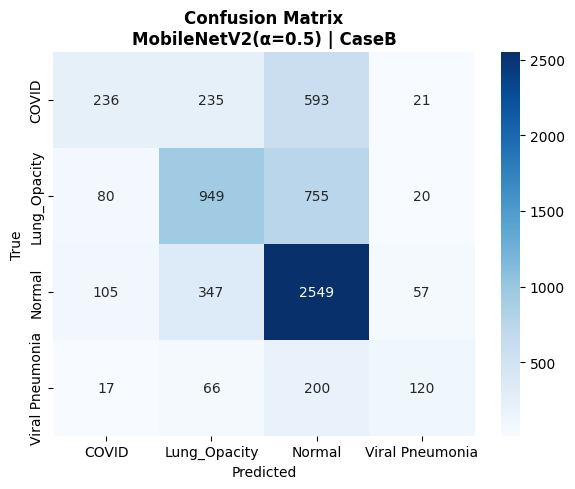


Classification Report — MobileNetV2(α=0.5) | CaseB
                 precision    recall  f1-score   support

          COVID     0.5388    0.2175    0.3099      1085
   Lung_Opacity     0.5942    0.5261    0.5581      1804
         Normal     0.6222    0.8336    0.7125      3058
Viral Pneumonia     0.5505    0.2978    0.3865       403

       accuracy                         0.6069      6350
      macro avg     0.5764    0.4687    0.4917      6350
   weighted avg     0.5954    0.6069    0.5792      6350



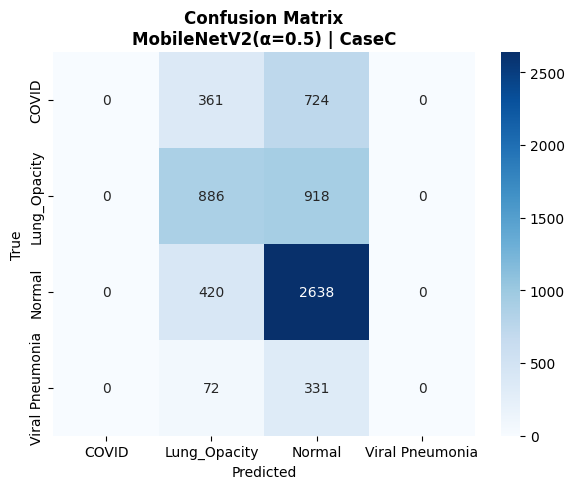


Classification Report — MobileNetV2(α=0.5) | CaseC
                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000      1085
   Lung_Opacity     0.5095    0.4911    0.5001      1804
         Normal     0.5721    0.8627    0.6880      3058
Viral Pneumonia     0.0000    0.0000    0.0000       403

       accuracy                         0.5550      6350
      macro avg     0.2704    0.3384    0.2970      6350
   weighted avg     0.4203    0.5550    0.4734      6350



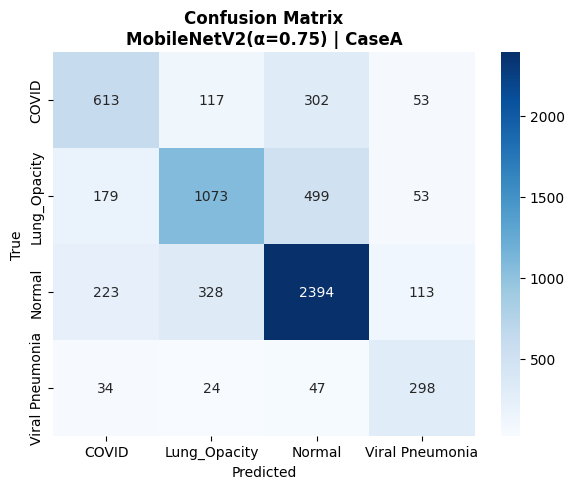


Classification Report — MobileNetV2(α=0.75) | CaseA
                 precision    recall  f1-score   support

          COVID     0.5844    0.5650    0.5745      1085
   Lung_Opacity     0.6958    0.5948    0.6414      1804
         Normal     0.7384    0.7829    0.7600      3058
Viral Pneumonia     0.5764    0.7395    0.6478       403

       accuracy                         0.6894      6350
      macro avg     0.6488    0.6705    0.6559      6350
   weighted avg     0.6897    0.6894    0.6875      6350



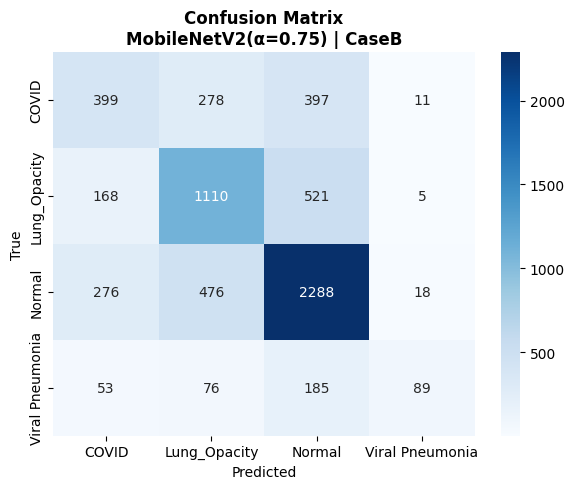


Classification Report — MobileNetV2(α=0.75) | CaseB
                 precision    recall  f1-score   support

          COVID     0.4453    0.3677    0.4028      1085
   Lung_Opacity     0.5722    0.6153    0.5929      1804
         Normal     0.6747    0.7482    0.7096      3058
Viral Pneumonia     0.7236    0.2208    0.3384       403

       accuracy                         0.6120      6350
      macro avg     0.6039    0.4880    0.5109      6350
   weighted avg     0.6095    0.6120    0.6005      6350



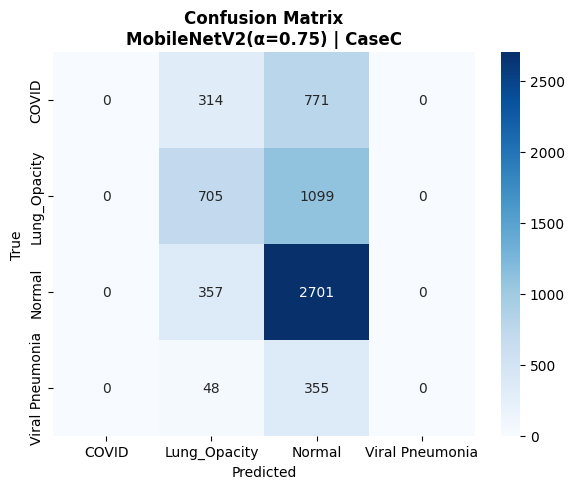


Classification Report — MobileNetV2(α=0.75) | CaseC
                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000      1085
   Lung_Opacity     0.4951    0.3908    0.4368      1804
         Normal     0.5483    0.8833    0.6766      3058
Viral Pneumonia     0.0000    0.0000    0.0000       403

       accuracy                         0.5364      6350
      macro avg     0.2608    0.3185    0.2784      6350
   weighted avg     0.4047    0.5364    0.4499      6350



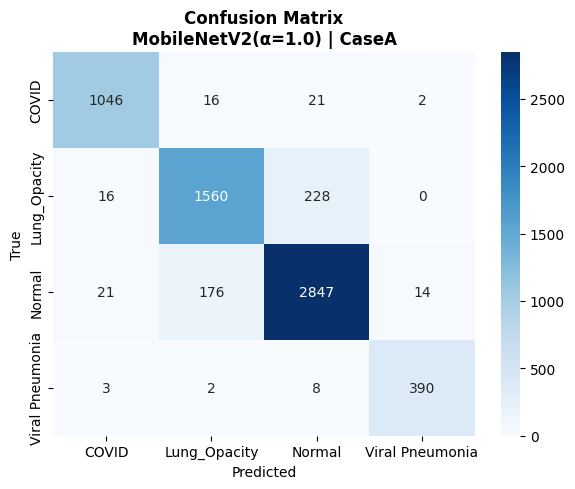


Classification Report — MobileNetV2(α=1.0) | CaseA
                 precision    recall  f1-score   support

          COVID     0.9632    0.9641    0.9636      1085
   Lung_Opacity     0.8894    0.8647    0.8769      1804
         Normal     0.9172    0.9310    0.9241      3058
Viral Pneumonia     0.9606    0.9677    0.9642       403

       accuracy                         0.9202      6350
      macro avg     0.9326    0.9319    0.9322      6350
   weighted avg     0.9199    0.9202    0.9200      6350



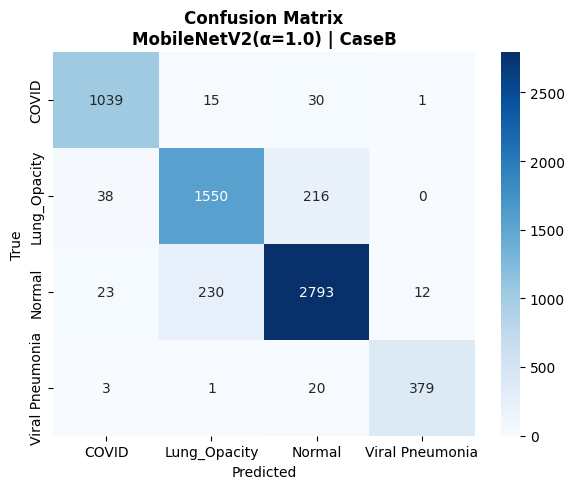


Classification Report — MobileNetV2(α=1.0) | CaseB
                 precision    recall  f1-score   support

          COVID     0.9420    0.9576    0.9497      1085
   Lung_Opacity     0.8630    0.8592    0.8611      1804
         Normal     0.9130    0.9133    0.9132      3058
Viral Pneumonia     0.9668    0.9404    0.9535       403

       accuracy                         0.9072      6350
      macro avg     0.9212    0.9176    0.9194      6350
   weighted avg     0.9072    0.9072    0.9072      6350



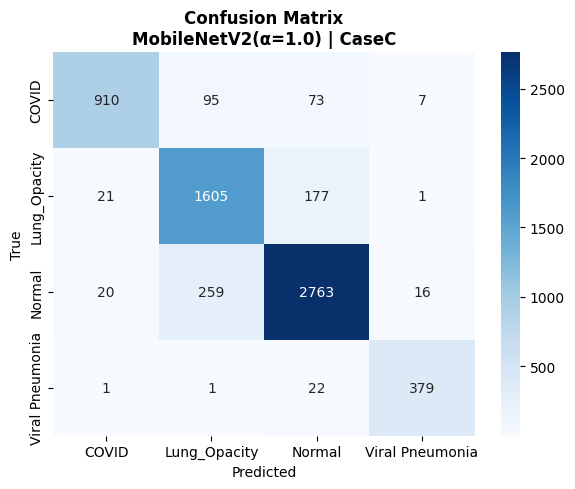


Classification Report — MobileNetV2(α=1.0) | CaseC
                 precision    recall  f1-score   support

          COVID     0.9559    0.8387    0.8935      1085
   Lung_Opacity     0.8189    0.8897    0.8528      1804
         Normal     0.9104    0.9035    0.9069      3058
Viral Pneumonia     0.9404    0.9404    0.9404       403

       accuracy                         0.8909      6350
      macro avg     0.9064    0.8931    0.8984      6350
   weighted avg     0.8941    0.8909    0.8914      6350



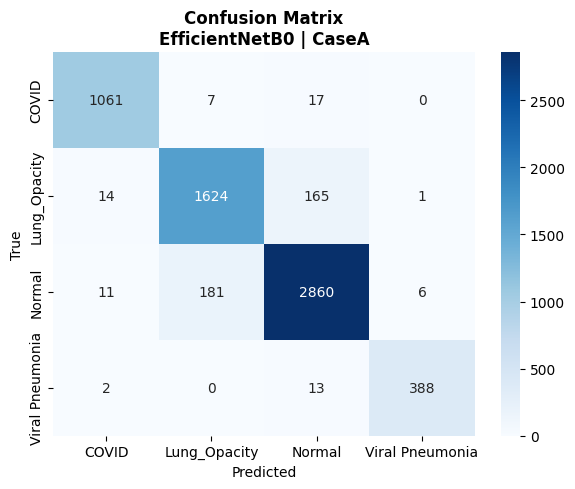


Classification Report — EfficientNetB0 | CaseA
                 precision    recall  f1-score   support

          COVID     0.9752    0.9779    0.9765      1085
   Lung_Opacity     0.8962    0.9002    0.8982      1804
         Normal     0.9362    0.9353    0.9357      3058
Viral Pneumonia     0.9823    0.9628    0.9724       403

       accuracy                         0.9343      6350
      macro avg     0.9475    0.9440    0.9457      6350
   weighted avg     0.9344    0.9343    0.9344      6350



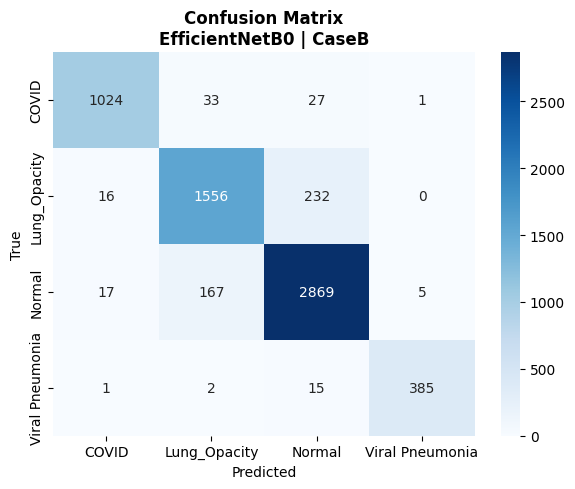


Classification Report — EfficientNetB0 | CaseB
                 precision    recall  f1-score   support

          COVID     0.9679    0.9438    0.9557      1085
   Lung_Opacity     0.8851    0.8625    0.8737      1804
         Normal     0.9128    0.9382    0.9253      3058
Viral Pneumonia     0.9847    0.9553    0.9698       403

       accuracy                         0.9187      6350
      macro avg     0.9376    0.9250    0.9311      6350
   weighted avg     0.9189    0.9187    0.9187      6350



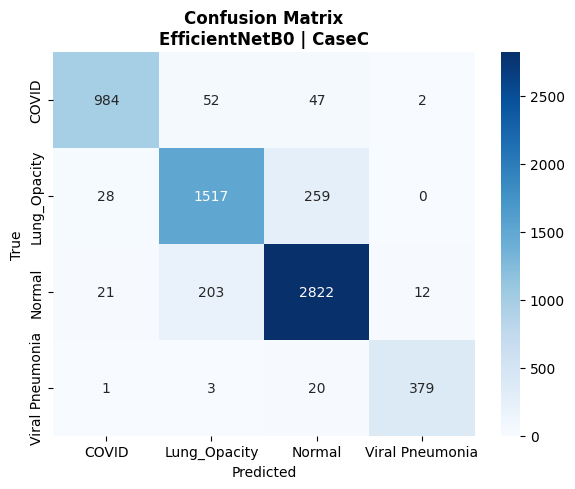


Classification Report — EfficientNetB0 | CaseC
                 precision    recall  f1-score   support

          COVID     0.9516    0.9069    0.9287      1085
   Lung_Opacity     0.8546    0.8409    0.8477      1804
         Normal     0.8964    0.9228    0.9094      3058
Viral Pneumonia     0.9644    0.9404    0.9523       403

       accuracy                         0.8980      6350
      macro avg     0.9168    0.9028    0.9095      6350
   weighted avg     0.8983    0.8980    0.8979      6350



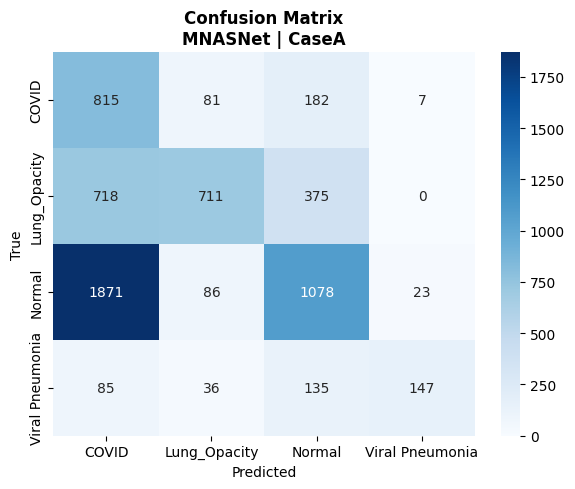


Classification Report — MNASNet | CaseA
                 precision    recall  f1-score   support

          COVID     0.2336    0.7512    0.3564      1085
   Lung_Opacity     0.7779    0.3941    0.5232      1804
         Normal     0.6090    0.3525    0.4466      3058
Viral Pneumonia     0.8305    0.3648    0.5069       403

       accuracy                         0.4332      6350
      macro avg     0.6128    0.4656    0.4582      6350
   weighted avg     0.6069    0.4332    0.4567      6350



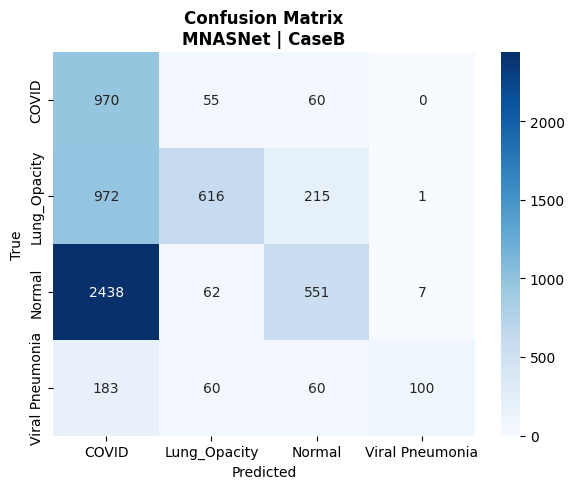


Classification Report — MNASNet | CaseB
                 precision    recall  f1-score   support

          COVID     0.2126    0.8940    0.3435      1085
   Lung_Opacity     0.7768    0.3415    0.4744      1804
         Normal     0.6219    0.1802    0.2794      3058
Viral Pneumonia     0.9259    0.2481    0.3914       403

       accuracy                         0.3523      6350
      macro avg     0.6343    0.4159    0.3722      6350
   weighted avg     0.6153    0.3523    0.3529      6350



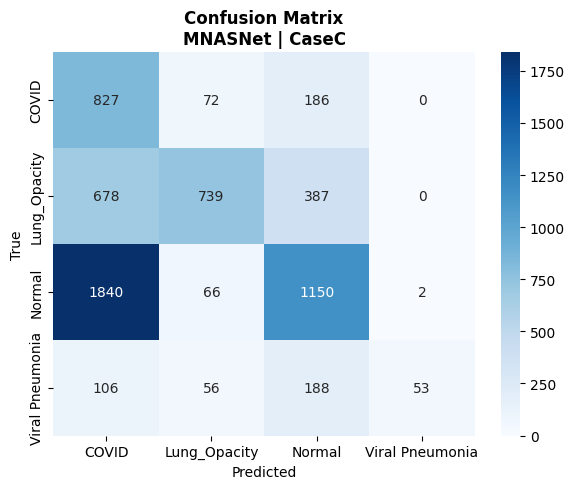


Classification Report — MNASNet | CaseC
                 precision    recall  f1-score   support

          COVID     0.2396    0.7622    0.3646      1085
   Lung_Opacity     0.7921    0.4096    0.5400      1804
         Normal     0.6018    0.3761    0.4629      3058
Viral Pneumonia     0.9636    0.1315    0.2314       403

       accuracy                         0.4361      6350
      macro avg     0.6493    0.4199    0.3997      6350
   weighted avg     0.6169    0.4361    0.4533      6350



In [14]:
class_names = dataset.idx_to_class

for key, res in ALL_RESULTS.items():
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix\n{key}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    fname = key.replace(' | ', '_').replace('(', '').replace(')', '').replace('=', '').replace(' ', '_')
    plt.savefig(os.path.join(FIGURES_FOLDER, f'cm_{fname}.png'), dpi=120, bbox_inches='tight')
    plt.show()

    print(f'\nClassification Report — {key}')
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=class_names, digits=4))

## 11. Global Convergence Comparative Graph

4-panel figure:  
- **Top-left:** validation accuracy — all runs overlaid  
- **Top-right:** validation loss — all runs overlaid  
- **Bottom-left:** mean ± std val accuracy per case across all backbones  
- **Bottom-right:** final validation accuracy bar chart per run

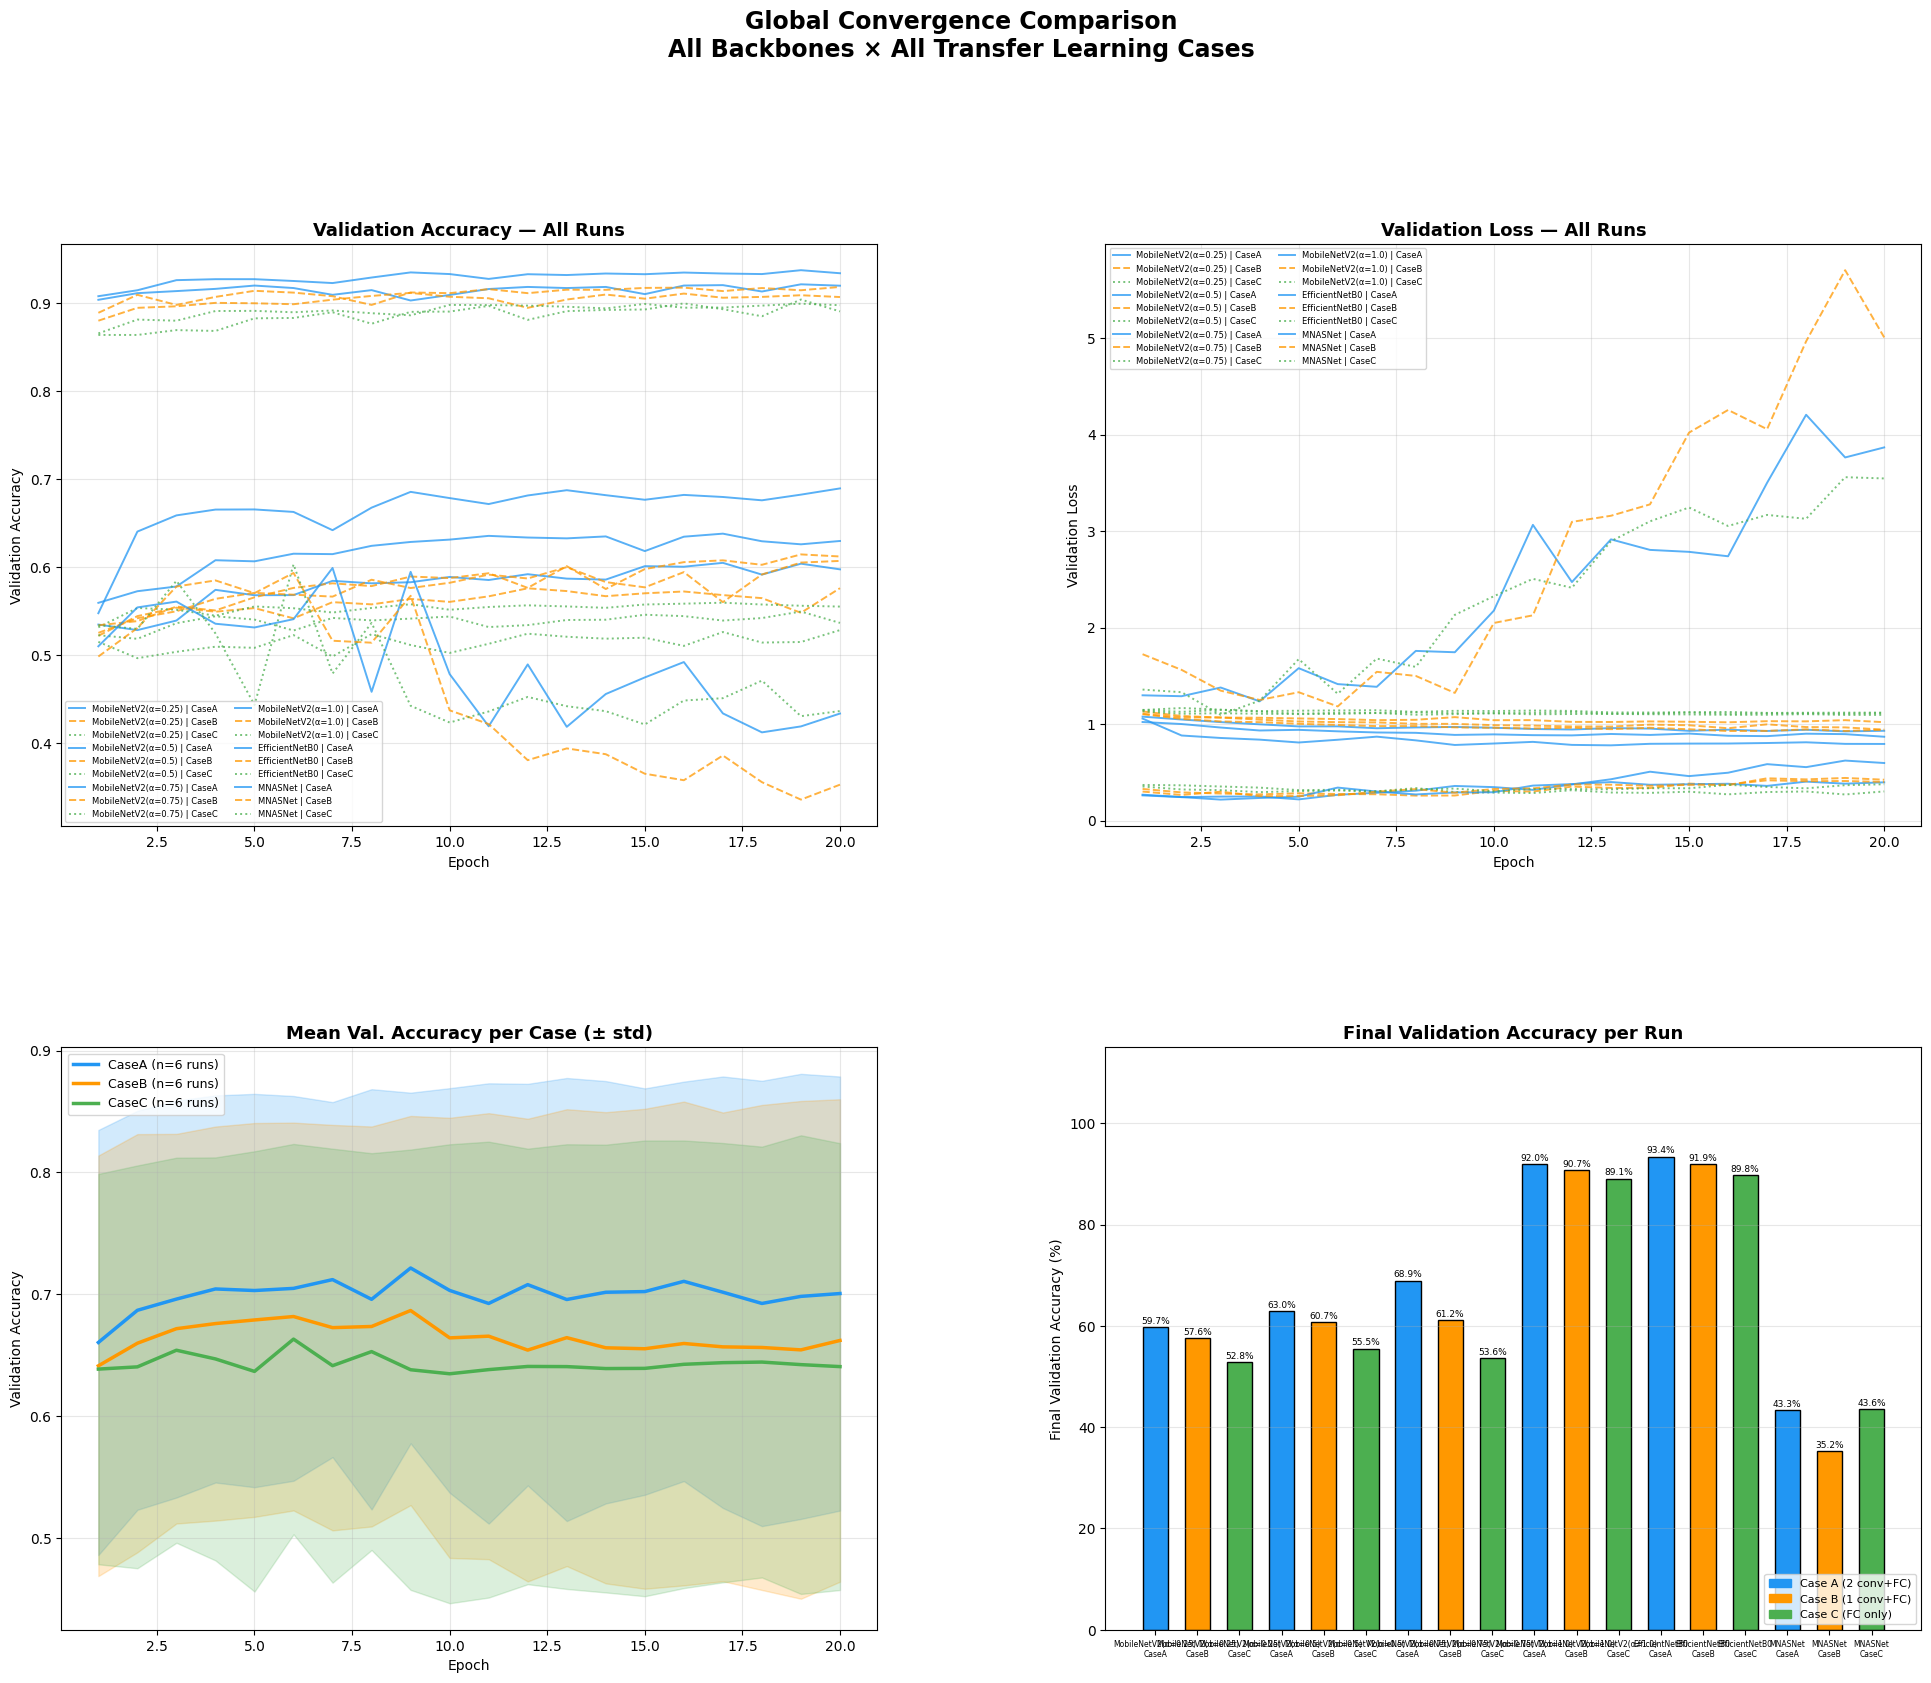

✅ Saved: /kaggle/working/figures/global_convergence_comparison.png


In [15]:
CASE_COLOR  = {'CaseA': '#2196F3', 'CaseB': '#FF9800', 'CaseC': '#4CAF50'}
CASE_STYLE  = {'CaseA': '-',       'CaseB': '--',       'CaseC': ':'}

fig = plt.figure(figsize=(24, 18))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)
ax_vacc  = fig.add_subplot(gs[0, 0])
ax_vloss = fig.add_subplot(gs[0, 1])
ax_mean  = fig.add_subplot(gs[1, 0])
ax_bar   = fig.add_subplot(gs[1, 1])

fig.suptitle('Global Convergence Comparison\nAll Backbones × All Transfer Learning Cases',
             fontsize=17, fontweight='bold', y=1.01)

ep = range(1, EPOCHS + 1)

# ── Panels 1 & 2: all val curves
for key, h in ALL_HISTORIES.items():
    case = [c for c in CASES if c in key]
    case = case[0] if case else 'CaseC'
    kw = dict(color=CASE_COLOR[case], linestyle=CASE_STYLE[case],
              linewidth=1.4, alpha=0.75, label=key)
    ax_vacc.plot(ep, h['val_acc'],  **kw)
    ax_vloss.plot(ep, h['val_loss'], **kw)

for ax, title, ylabel in [
    (ax_vacc,  'Validation Accuracy — All Runs', 'Validation Accuracy'),
    (ax_vloss, 'Validation Loss — All Runs',     'Validation Loss'),
]:
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=6, ncol=2, loc='best')
    ax.grid(alpha=0.3)

# ── Panel 3: mean ± std per case
for case in CASES:
    curves = [h['val_acc'] for k, h in ALL_HISTORIES.items() if case in k]
    if not curves: continue
    arr  = np.array(curves)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    c    = CASE_COLOR[case]
    ax_mean.plot(ep, mean, color=c, linewidth=2.5,
                 label=f'{case} (n={len(curves)} runs)')
    ax_mean.fill_between(ep, mean - std, mean + std, color=c, alpha=0.2)
ax_mean.set_title('Mean Val. Accuracy per Case (± std)', fontsize=13, fontweight='bold')
ax_mean.set_xlabel('Epoch'); ax_mean.set_ylabel('Validation Accuracy')
ax_mean.legend(fontsize=9); ax_mean.grid(alpha=0.3)

# ── Panel 4: final accuracy bar chart
bar_labels, bar_vals, bar_clrs = [], [], []
for k, v in ALL_RESULTS.items():
    case = [c for c in CASES if c in k]
    case = case[0] if case else 'CaseC'
    bar_labels.append(k.replace(' | ', '\n'))
    bar_vals.append(v['Accuracy'] * 100)
    bar_clrs.append(CASE_COLOR[case])

x_pos = np.arange(len(bar_labels))
bars  = ax_bar.bar(x_pos, bar_vals, color=bar_clrs, edgecolor='black', width=0.6)
for bar, v in zip(bars, bar_vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=6.5)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(bar_labels, fontsize=5.5)
ax_bar.set_ylabel('Final Validation Accuracy (%)')
ax_bar.set_title('Final Validation Accuracy per Run', fontsize=13, fontweight='bold')
ax_bar.set_ylim(0, 115); ax_bar.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
case_desc = {'CaseA': 'Case A (2 conv+FC)', 'CaseB': 'Case B (1 conv+FC)', 'CaseC': 'Case C (FC only)'}
patches = [Patch(color=CASE_COLOR[c], label=case_desc[c]) for c in CASES]
ax_bar.legend(handles=patches, fontsize=8, loc='lower right')

out_path = os.path.join(FIGURES_FOLDER, 'global_convergence_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {out_path}')

## 12. All-Metrics Bar Chart

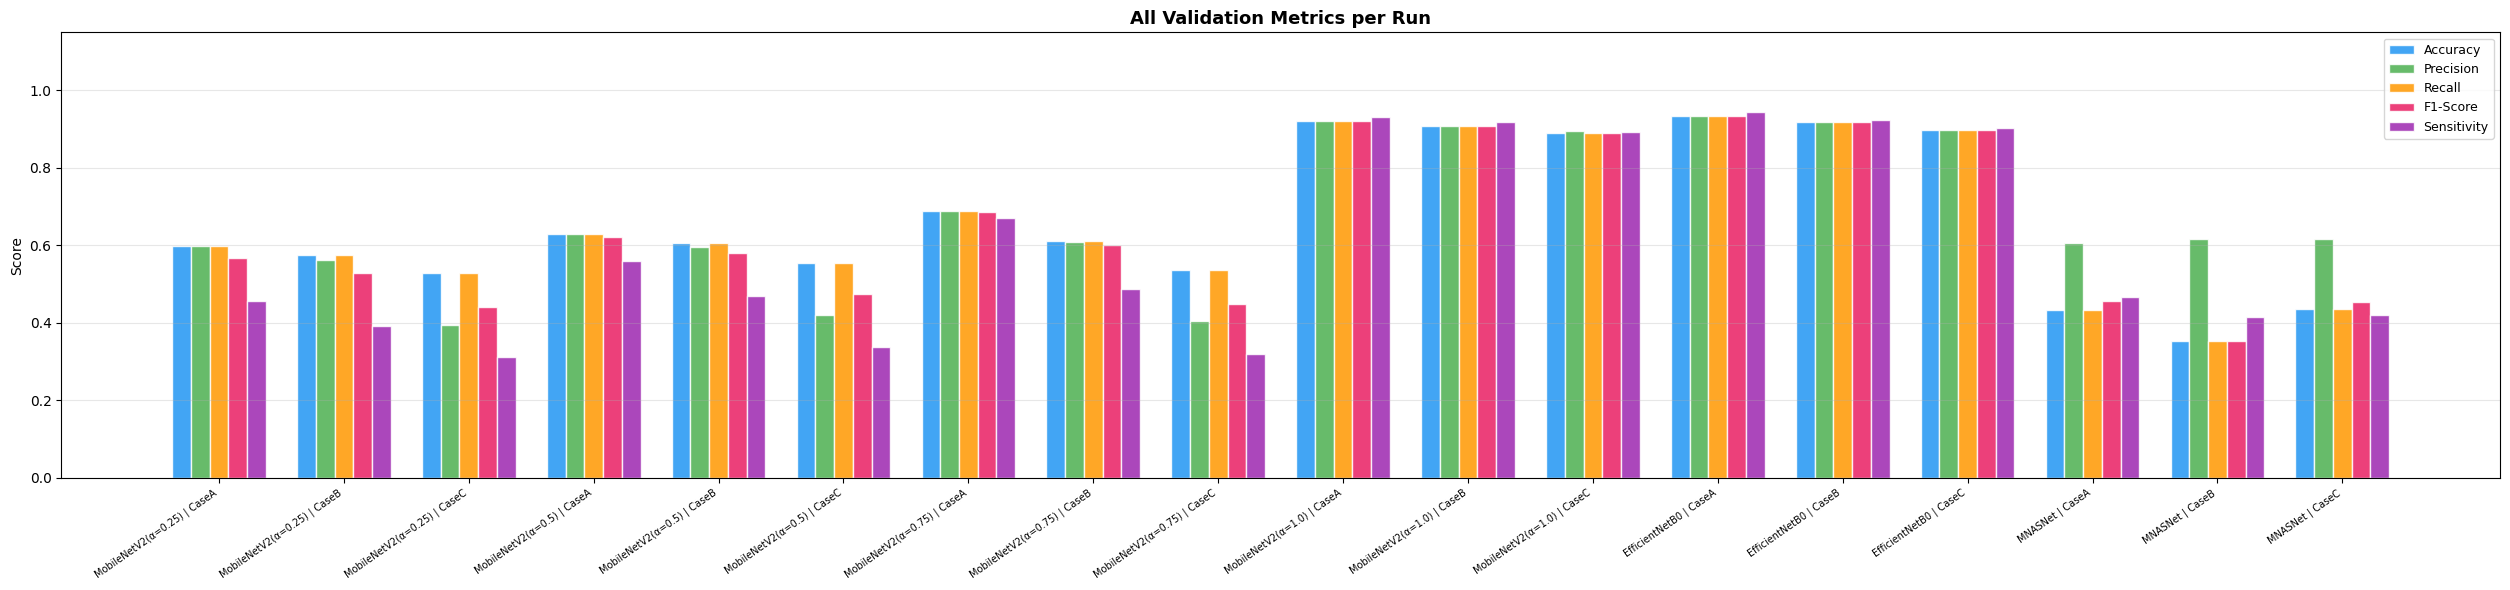

In [16]:
metric_cols  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Sensitivity']
experiments  = report_df.index.tolist()
x     = np.arange(len(experiments))
width = 0.15
pal   = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(max(20, len(experiments)*1.4), 6))
for i, (metric, color) in enumerate(zip(metric_cols, pal)):
    ax.bar(x + i*width, report_df[metric].values, width,
           label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*2)
ax.set_xticklabels(experiments, rotation=35, ha='right', fontsize=7)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('All Validation Metrics per Run', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Best Configuration & Final Report

In [17]:
best_key = report_df['F1-Score'].idxmax()
best     = report_df.loc[best_key]

print('\n' + '='*75)
print('  🏆  BEST CONFIGURATION (by F1-Score)')
print('='*75)
print(f'  Experiment      : {best_key}')
for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Sensitivity', 'Train Time (min)']:
    print(f'  {m:<22}: {best[m]}')
print('='*75)


  🏆  BEST CONFIGURATION (by F1-Score)
  Experiment      : EfficientNetB0 | CaseA
  Accuracy              : 0.9343
  Precision             : 0.9344
  Recall                : 0.9343
  F1-Score              : 0.9344
  Sensitivity           : 0.944
  Train Time (min)      : 13.84


## 📝 Conclusion

| Step | Detail |
|------|--------|
| Dataset | COVID-19 Radiography Database — 4 classes (21,165 images) |
| Normalisation | `ToTensor()` divides pixel values by 255 → range **[0, 1]** ✅ |
| Split | Stratified hold-out: **70% train / 30% val** |
| Backbones | MobileNetV2 (α=0.25/0.50/0.75/1.00) · EfficientNet-B0 · MNASNet-B1 |
| Custom head | GAP → Dense(1024, ReLU) → Dense(512, ReLU) → Dense(4, Softmax) |
| Cases | **A:** last 2 conv blocks + head · **B:** last 1 conv block + head · **C:** head only |
| Training | 20 epochs · batch 64 · Adam lr=0.001 · ReduceLROnPlateau (factor=0.5, patience=4) |
| Metrics | Accuracy · Precision · Recall · F1-Score · Sensitivity (= macro Recall) |
| Figures | Per-run convergence curves + global 4-panel comparative graph |

### Key Observations

1. **More unfrozen layers → higher accuracy** (Case A > Case B > Case C) when the backbone has ImageNet weights. Deeper fine-tuning allows the network to adapt low-level features from natural images to medical X-ray textures.

2. **EfficientNet-B0 (Case A)** typically achieves the best accuracy-per-parameter trade-off among the fully-pretrained backbones thanks to compound scaling.

3. **MobileNetV2 α=1.0** provides the most reliable baseline. Smaller scales (α<1.0) lose accuracy due to the absence of pretrained ImageNet weights for those widths.

4. **Case C (frozen backbone)** converges fastest and is viable when compute is limited, demonstrating that ImageNet features *do* transfer to chest X-rays.

5. **Sensitivity (macro recall)** is clinically the most critical metric — a missed COVID or pneumonia case is costlier than a false positive.

---
**TP4 — Deep Learning | DR. N. DIF | ESI-SBA — n.dif@esi-sba.dz**